# First analysis of dataset

In [60]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from ysights import *
import networkx as nx

In [61]:
db_path = 'data/1k_60d_FollowerPopularity_BA_database.db'

## Using ***sqlite3***

In [62]:
# database connection
conn = sqlite3.connect(db_path)

# List available tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

               name
0   sqlite_sequence
1          hashtags
2     post_hashtags
3          mentions
4          emotions
5     post_emotions
6            rounds
7            follow
8         reactions
9          websites
10         articles
11  recommendations
12           voting
13    user_interest
14        interests
15      post_topics
16        user_mgmt
17           images
18             post
19   article_topics
20   post_sentiment
21    post_toxicity


### Database and tables exploration

**Database description:**
- user_mgmt: contains the agents’ metadata;
- articles: contains the news articles that agents shared;
- websites: contains the websites whose articles shared by the agents;
- emotions: contains the emotions that contents can elicit;
- follow: contains the social connections between agents;
- hashtags: contains the hashtags used by agents;
- images: contains the images (along with their LLM textual annotation) shared by agents;
- post: contains the posts/comments shared by agents;
- post_emotions: contains the emotions elicited by agents’ contents;
- post_hashtags: contains the hashtags used by agents in their contents;
- post_sentiment: contains the VADER sentiment annotations of agents’ generated contents;
- post_toxicity: contains the Perspective API toxicity annotations of agents’ generated contents;
- post_topics: contains the topics (i.e., interests) of agents’ generated contents;
- interests: contains the interests (i.e., topics) used in the simulation;
- user_interest: contains the interests (i.e., topics) used by agents to generate content;
- voting: contains the votes cast by agents (if the “cast” action is enabled);
- mentions: contains the mentions between agents;
- reactions: contains the reactions to agents contents;
- recommendations: contains the content recommendations provided by the server to agents;
- rounds: contains the simulation rounds.

5 of these tables are empty (articles, websites, images, post_toxicity, voting).

In [63]:
print(pd.read_sql("SELECT COUNT(id) FROM user_mgmt;", conn))
pd.read_sql("SELECT * FROM user_mgmt LIMIT 5;", conn)

   COUNT(id)
0        994


,id,username,email,password,user_type,leaning,age,oe,co,ex,...,joined_on,frecsys_type,round_actions,gender,nationality,toxicity,is_page,left_on,daily_activity_level,profession
0,1,Admin,admin@ysocial.com,pbkdf2:sha256:260000$tjP4Gh0VVkutjhoM$89a93257...,user,none,0,None,None,None,...,0,default,3,None,None,none,0,None,1,None
1,2,Mrs.KimberlyWard,Mrs.KimberlyWard@ysocial.it,Mrs.KimberlyWard,sushruth/solar-uncensored:latest,democrat,48,consistent/cautious,extravagant/careless,outgoing/energetic,...,1,PreferentialAttachment,2,female,American,high,0,None,3,Athlete
2,3,WilliamCruz,WilliamCruz@ysocial.it,WilliamCruz,sushruth/solar-uncensored:latest,republican,26,inventive/curious,efficient/organized,outgoing/energetic,...,1,PreferentialAttachment,2,male,American,low,0,None,1,Blacksmith
3,4,KellyGonzalez,KellyGonzalez@ysocial.it,KellyGonzalez,sushruth/solar-uncensored:latest,republican,46,inventive/curious,efficient/organized,outgoing/energetic,...,1,PreferentialAttachment,3,female,American,none,0,None,2,Dentist
4,5,TiffanyArroyo,TiffanyArroyo@ysocial.it,TiffanyArroyo,sushruth/solar-uncensored:latest,democrat,49,inventive/curious,extravagant/careless,outgoing/energetic,...,1,PreferentialAttachment,1,female,American,low,0,None,3,Fast Food Worker


In [64]:
print(pd.read_sql("SELECT COUNT(id) FROM articles;", conn))
pd.read_sql("SELECT * FROM articles LIMIT 5;", conn)

   COUNT(id)
0          0


,id,title,summary,website_id,fetched_on,link


In [65]:
print(pd.read_sql("SELECT COUNT(id) FROM websites;", conn))
pd.read_sql("SELECT * FROM websites LIMIT 5;", conn)

   COUNT(id)
0          0


,id,name,rss,leaning,category,last_fetched,country,language


In [66]:
print(pd.read_sql("SELECT COUNT(id) FROM emotions;", conn))
pd.read_sql("SELECT * FROM emotions LIMIT 5;", conn)

   COUNT(id)
0         28


,id,emotion,icon
0,1,amusement,mdi-emoticon-happy
1,2,admiration,mdi-weather-sunny
2,3,anger,mdi-emoticon-devil
3,4,annoyance,mdi-emoticon-tongue
4,5,approval,mdi-thumb-up-outline


In [67]:
print(pd.read_sql("SELECT COUNT(id) FROM follow;", conn))
pd.read_sql("SELECT * FROM follow LIMIT 5;", conn)

   COUNT(id)
0      59435


,user_id,follower_id,id,action,round
0,2,3,1,follow,0
1,2,4,2,follow,0
2,2,5,3,follow,0
3,2,6,4,follow,0
4,2,7,5,follow,0


In [68]:
print(pd.read_sql("SELECT COUNT(id) FROM hashtags;", conn))
pd.read_sql("SELECT * FROM hashtags LIMIT 5;", conn)

   COUNT(id)
0      53069


,hashtag,id
0,#Tech,1
1,#ThursdayThoughts,2
2,#FutureofDigitalActivism,3
3,#InnovationMatters,4
4,#TechnologyProgress,5


In [69]:
print(pd.read_sql("SELECT COUNT(id) FROM images;", conn))
pd.read_sql("SELECT * FROM images LIMIT 5;", conn)

   COUNT(id)
0          0


,id,url,description,article_id


In [70]:
print(pd.read_sql("SELECT COUNT(id) FROM post;", conn))
pd.read_sql("SELECT * FROM post LIMIT 5;", conn)

   COUNT(id)
0      71486


,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count
0,1,Am seriously amazed by how #Tech has evolved &...,None,298,-1,1,1,None,-1,None,3
1,2,Just discovered the newest productivity app & ...,None,813,-1,2,1,None,-1,None,1
2,3,@DanielHenry Technology has completely reshape...,None,813,1,1,1,None,-1,None,1
3,4,"@EmmaPatel That's impressive, Ms.Patel 😊 I per...",None,857,2,2,1,None,-1,None,3
4,5,@EmmaPatel Exciting times indeed that we live ...,None,857,1,1,1,None,-1,None,2


In [71]:
print(pd.read_sql("SELECT COUNT(id) FROM post_emotions;", conn))
pd.read_sql("SELECT * FROM post_emotions LIMIT 5;", conn)

   COUNT(id)
0     102400


,id,post_id,emotion_id
0,1,1,2
1,2,1,9
2,3,1,14
3,4,1,21
4,5,2,1


In [72]:
print(pd.read_sql("SELECT COUNT(id) FROM post_hashtags;", conn))
pd.read_sql("SELECT * FROM post_hashtags LIMIT 5;", conn)

   COUNT(id)
0      82929


,post_id,hashtag_id,id
0,1,1,1
1,1,2,2
2,1,3,3
3,3,4,4
4,3,5,5


In [73]:
print(pd.read_sql("SELECT COUNT(id) FROM post_sentiment;", conn))
pd.read_sql("SELECT * FROM post_sentiment LIMIT 5;", conn)

   COUNT(id)
0     187433


,id,post_id,neg,pos,neu,compound,user_id,round,sentiment_parent,topic_id,is_post,is_comment,is_reaction
0,1,1,0.06,0.124,0.816,0.4199,298,1,,11,1,0,0
1,2,2,0.00,0.344,0.656,0.9115,813,1,,14,1,0,0
2,3,3,0.00,0.229,0.771,0.8225,813,1,pos,11,0,1,0
3,4,1,0.00,1.000,0.000,1.0000,813,1,pos,11,0,0,1
4,5,4,0.00,0.326,0.674,0.9186,857,1,pos,14,0,1,0


In [74]:
print(pd.read_sql("SELECT COUNT(id) FROM post_toxicity;", conn))
pd.read_sql("SELECT * FROM post_toxicity LIMIT 5;", conn)

   COUNT(id)
0          0


,id,post_id,toxicity,severe_toxicity,identity_attack,insult,profanity,threat,sexually_explicit,flirtation


In [75]:
print(pd.read_sql("SELECT COUNT(id) FROM post_topics;", conn))
pd.read_sql("SELECT * FROM post_topics LIMIT 5;", conn)

   COUNT(id)
0      20427


,id,post_id,topic_id
0,1,1,11
1,2,2,14
2,3,12,4
3,4,12,2
4,5,16,4


In [76]:
print(pd.read_sql("SELECT COUNT(iid) FROM interests;", conn))
pd.read_sql("SELECT * FROM interests LIMIT 5;", conn)

   COUNT(iid)
0          15


,iid,interest
0,1,Weekend Routines
1,2,Influencer Responsibility
2,3,Dating Apps
3,4,Cancel Culture
4,5,Creative Projects


In [77]:
print(pd.read_sql("SELECT COUNT(id) FROM user_interest;", conn))
pd.read_sql("SELECT * FROM user_interest LIMIT 5;", conn)

   COUNT(id)
0     123093


,id,user_id,interest_id,round_id
0,1,2,1,1
1,2,2,2,1
2,3,2,3,1
3,4,3,4,1
4,5,3,5,1


In [78]:
print(pd.read_sql("SELECT COUNT(vid) FROM voting;", conn))
pd.read_sql("SELECT * FROM voting LIMIT 5;", conn)

   COUNT(vid)
0           0


,vid,round,user_id,preference,content_type,content_id


In [79]:
print(pd.read_sql("SELECT COUNT(id) FROM mentions;", conn))
pd.read_sql("SELECT * FROM mentions LIMIT 5;", conn)

   COUNT(id)
0      50630


,id,user_id,post_id,round,answered
0,1,298,3,1,1
1,2,813,4,1,0
2,3,813,5,1,0
3,4,857,6,1,1
4,5,298,6,1,1


In [80]:
print(pd.read_sql("SELECT COUNT(id) FROM reactions;", conn))
pd.read_sql("SELECT * FROM reactions LIMIT 5;", conn)

   COUNT(id)
0      35342


,id,post_id,user_id,type,round
0,1,1,813,like,1
1,2,2,857,like,1
2,3,1,857,like,1
3,4,3,545,like,1
4,5,5,545,like,1


In [81]:
print(pd.read_sql("SELECT COUNT(id) FROM recommendations;", conn))
pd.read_sql("SELECT * FROM recommendations LIMIT 5;", conn)

   COUNT(id)
0      44557


,id,user_id,post_ids,round
0,1,813,1,1
1,2,857,3|2|1,1
2,3,857,3|2|3|2|1,1
3,4,860,5|4|3|2,1
4,5,545,6|5|4|3,1


In [82]:
print(pd.read_sql("SELECT COUNT(id) FROM rounds;", conn))
print(pd.read_sql("SELECT COUNT(id) FROM rounds WHERE day=0;", conn))
print(pd.read_sql("SELECT COUNT(id) FROM rounds WHERE day=23;", conn))
print(pd.read_sql("SELECT COUNT(id) FROM rounds WHERE day=45;", conn))
print(pd.read_sql("SELECT COUNT(id) FROM rounds WHERE day=59;", conn))
print(pd.read_sql("SELECT COUNT(DISTINCT day) FROM rounds;", conn))
pd.read_sql("SELECT * FROM rounds LIMIT 5;", conn)

   COUNT(id)
0       1444
   COUNT(id)
0         34
   COUNT(id)
0         24
   COUNT(id)
0         24
   COUNT(id)
0         18
   COUNT(DISTINCT day)
0                   60


,id,day,hour
0,1,0,0
1,2,0,1
2,3,0,2
3,4,0,3
4,5,0,4


In table *rounds* there are 60 days and 1444 rounds. Usually 1 round = 1 hour. The first and the last days are exceptions.

However, as we can see not all tables have the same number of rounds. Possible that not in every round there is an action.

In [83]:
# check number of rounds in post
pd.read_sql("SELECT COUNT(DISTINCT ROUND) FROM post;", conn)

,COUNT(DISTINCT ROUND)
0,1359


In [84]:
# check number of rounds in follow
pd.read_sql("SELECT COUNT(DISTINCT ROUND) FROM follow;", conn)

,COUNT(DISTINCT ROUND)
0,1360


**Summary**

🔹 **Kluczowe tabele dla Twojej analizy:**

user_mgmt
→ Fundament Twojej analizy.
Zawiera metadane o agentach: typ użytkownika, ideologia (leaning), cechy osobowości (co, ex, ag, ne – zapewne Big Five), zainteresowania, poziom edukacji itp.
Umożliwia identyfikację person i grup agentów, które potem możesz zestawiać z ich pozycją w sieci.

follow
→ Najważniejsza strukturalnie tabela.
Zawiera połączenia między agentami (user_id – followed_id) oraz ewentualną akcję i rundę symulacji.
To właśnie z niej zbudujesz graf relacji (sieć społecznościową).
Możesz obliczać: centralność, modularność, asortatywność, rdzeń–peryferie, k-core, itp.

mentions i reactions
→ Kluczowe do modelowania interakcji dynamicznych.

mentions pozwala zbudować graf komunikacji (kto z kim rozmawia).

reactions (np. „like”, „share”) daje wagę krawędzi (intensywność relacji).
Dzięki temu możesz analizować warstwę interakcji (obok followerów).

post
→ Ważna warstwa pośrednia między agentem a siecią.
Zawiera treści generowane przez agentów, identyfikatory użytkowników, emocje, itp.
Możesz z niej wyciągnąć liczbę postów, rytm aktywności, poziom zaangażowania, czyli indywidualne wskaźniki zachowań.

recommendations (opcjonalnie, ale wartościowa)
→ Pokazuje, jaki content był rekomendowany poszczególnym agentom.
Pozwala badać ekspozycję i jej wpływ na pozycję w sieci (ważne, jeśli chcesz zahaczyć o przyczynowość / dynamikę rewiringu).

🔸 **Tabele pomocnicze (możesz uwzględnić, ale nie są centralne):**

emotions, post_emotions, post_sentiment – jeśli chcesz analizować ton emocjonalny komunikacji (np. polaryzacja afektywna).

interests, post_topics, user_interest – mogą posłużyć do analizy homofilii tematycznej.

rounds – przydatne do analizy dynamiki w czasie (np. stabilność pozycji w kolejnych rundach).

🔹 **Sugerowane połączenie dla Twojej analizy:**

Sieć główna: follow lub mentions

Atrybuty węzłów: z user_mgmt

Wagi krawędzi / aktywność: z reactions

Czas / zmiany: z rounds

🔹 **Najważniejsze dla Twojego celu:**

👉 user_mgmt + follow + mentions (+ reactions)
To cztery tabele, które w pełni wystarczą do zbadania:

różnic w pozycji sieciowej między grupami (np. ideologia, osobowość),

stabilności pozycji w czasie (jeśli rounds jest aktywne),

identyfikowalności agentów po wzorcach interakcji (sygnatura strukturalna).

### User_mgmt analysis

We already checked that there is 994 users.

In [85]:
users = pd.read_sql("SELECT * FROM user_mgmt;", conn)
users.columns

Index(['id', 'username', 'email', 'password', 'user_type', 'leaning', 'age',
       'oe', 'co', 'ex', 'ag', 'ne', 'recsys_type', 'language', 'owner',
       'education_level', 'joined_on', 'frecsys_type', 'round_actions',
       'gender', 'nationality', 'toxicity', 'is_page', 'left_on',
       'daily_activity_level', 'profession'],
      dtype='object')

In [86]:
users[['leaning', 'age',
       'oe', 'co', 'ex', 'ag', 'ne', 'language',
       'education_level',
       'gender', 'nationality', 'toxicity', 'left_on',
       'daily_activity_level', 'profession']].head()

,leaning,age,oe,co,ex,ag,ne,language,education_level,gender,nationality,toxicity,left_on,daily_activity_level,profession
0,none,0,None,None,None,None,None,en,None,None,None,none,None,1,None
1,democrat,48,consistent/cautious,extravagant/careless,outgoing/energetic,critical/judgmental,resilient/confident,English,master,female,American,high,None,3,Athlete
2,republican,26,inventive/curious,efficient/organized,outgoing/energetic,critical/judgmental,sensitive/nervous,English,high school,male,American,low,None,1,Blacksmith
3,republican,46,inventive/curious,efficient/organized,outgoing/energetic,critical/judgmental,resilient/confident,English,bachelor,female,American,none,None,2,Dentist
4,democrat,49,inventive/curious,extravagant/careless,outgoing/energetic,friendly/compassionate,resilient/confident,English,master,female,American,low,None,3,Fast Food Worker


In [87]:
users.drop([0], inplace=True) # delete Admin
users.head()

,id,username,email,password,user_type,leaning,age,oe,co,ex,...,joined_on,frecsys_type,round_actions,gender,nationality,toxicity,is_page,left_on,daily_activity_level,profession
1,2,Mrs.KimberlyWard,Mrs.KimberlyWard@ysocial.it,Mrs.KimberlyWard,sushruth/solar-uncensored:latest,democrat,48,consistent/cautious,extravagant/careless,outgoing/energetic,...,1,PreferentialAttachment,2,female,American,high,0,None,3,Athlete
2,3,WilliamCruz,WilliamCruz@ysocial.it,WilliamCruz,sushruth/solar-uncensored:latest,republican,26,inventive/curious,efficient/organized,outgoing/energetic,...,1,PreferentialAttachment,2,male,American,low,0,None,1,Blacksmith
3,4,KellyGonzalez,KellyGonzalez@ysocial.it,KellyGonzalez,sushruth/solar-uncensored:latest,republican,46,inventive/curious,efficient/organized,outgoing/energetic,...,1,PreferentialAttachment,3,female,American,none,0,None,2,Dentist
4,5,TiffanyArroyo,TiffanyArroyo@ysocial.it,TiffanyArroyo,sushruth/solar-uncensored:latest,democrat,49,inventive/curious,extravagant/careless,outgoing/energetic,...,1,PreferentialAttachment,1,female,American,low,0,None,3,Fast Food Worker
5,6,AlexanderGarcia,AlexanderGarcia@ysocial.it,AlexanderGarcia,sushruth/solar-uncensored:latest,democrat,34,consistent/cautious,extravagant/careless,solitary/reserved,...,1,PreferentialAttachment,3,male,American,high,0,None,2,Blacksmith


In [88]:
users['leaning'].value_counts()

leaning
republican    498
democrat      495
Name: count, dtype: int64

In [89]:
users['oe'].value_counts() # openness

oe
inventive/curious      508
consistent/cautious    485
Name: count, dtype: int64

In [90]:
users['co'].value_counts() # conscientiousness

co
efficient/organized     502
extravagant/careless    491
Name: count, dtype: int64

In [91]:
users['ex'].value_counts() # extraversion

ex
outgoing/energetic    512
solitary/reserved     481
Name: count, dtype: int64

In [92]:
users['ag'].value_counts() # agreeableness

ag
critical/judgmental       499
friendly/compassionate    494
Name: count, dtype: int64

In [93]:
users['ne'].value_counts() # neuroticism

ne
resilient/confident    501
sensitive/nervous      492
Name: count, dtype: int64

Columns related to Big Five personality description have categorical values. The distribution is balanced.

All users are American and speak english.

In [94]:
users['education_level'].value_counts()

education_level
bachelor       267
master         249
phd            241
high school    236
Name: count, dtype: int64

In [95]:
users['gender'].value_counts()

gender
male      497
female    496
Name: count, dtype: int64

In [96]:
users['profession'].value_counts()

profession
Fisherman              21
Busker                 15
Physiotherapist        15
IT Technician          14
Construction Worker    14
                       ..
Factory Worker          3
Butcher                 3
Yoga Instructor         3
Personal Assistant      2
Pharmacist              1
Name: count, Length: 120, dtype: int64

In general since data are synthetic distribution of each column is balanced. It is good baseline to define and create personalities.

The 'profession' column could be the problematic one, it has 120 distinct categories, and it is not balanced. We cluster it manually into meaningful groups.

Below the mapping of professions.

#### Professions mapping

In [97]:
cluster_map = {
    "Professor": "Science_Academia",
    "Researcher": "Science_Academia",
    "Scientist": "Science_Academia",
    "Teacher": "Science_Academia",
    "Tutor": "Science_Academia",
    "Librarian": "Science_Academia",
    "School Counselor": "Science_Academia",
    "Psychologist": "Science_Academia",
    "Archaeologist": "Science_Academia",
    "Biologist": "Science_Academia",
    "Astronomer": "Science_Academia",

    "Surgeon": "Healthcare",
    "Nurse": "Healthcare",
    "Doctor": "Healthcare",
    "Dentist": "Healthcare",
    "Physiotherapist": "Healthcare",
    "Paramedic": "Healthcare",
    "Veterinarian": "Healthcare",
    "Medical Assistant": "Healthcare",
    "Home Health Aide": "Healthcare",
    "Caregiver": "Healthcare",
    "Pharmacist": "Healthcare",
    "Personal Trainer": "Healthcare",

    "IT Technician": "Technology",
    "Network Administrator": "Technology",
    "Software Engineer": "Technology",
    "Web Developer": "Technology",
    "Cybersecurity Analyst": "Technology",
    "Data Scientist": "Technology",
    "Robotics Engineer": "Technology",
    "Electrical Engineer": "Technology",
    "Mechanical Engineer": "Technology",
    "Civil Engineer": "Technology",

    "Lawyer": "Law_Finance_Admin",
    "Judge": "Law_Finance_Admin",
    "Paralegal": "Law_Finance_Admin",
    "Accountant": "Law_Finance_Admin",
    "Human Resources Manager": "Law_Finance_Admin",
    "Business Consultant": "Law_Finance_Admin",
    "Financial Analyst": "Law_Finance_Admin",
    "Stockbroker": "Law_Finance_Admin",
    "Bank Teller": "Law_Finance_Admin",
    "Entrepreneur": "Law_Finance_Admin",
    "Real Estate Agent": "Law_Finance_Admin",

    "Dancer": "Arts_Media",
    "Musician": "Arts_Media",
    "Photographer": "Arts_Media",
    "Filmmaker": "Arts_Media",
    "Actor": "Arts_Media",
    "Comedian": "Arts_Media",
    "Tattoo Artist": "Arts_Media",
    "Writer": "Arts_Media",
    "Graphic Designer": "Arts_Media",
    "Clown": "Arts_Media",
    "Fortune Teller": "Arts_Media",

    "Construction Worker": "Skilled_Trades",
    "Mechanic": "Skilled_Trades",
    "Electrician": "Skilled_Trades",
    "Plumber": "Skilled_Trades",
    "Welder": "Skilled_Trades",
    "Blacksmith": "Skilled_Trades",
    "Handyman": "Skilled_Trades",
    "Carpenter": "Skilled_Trades",
    "Textile Worker": "Skilled_Trades",

    "Farmer": "Agriculture",
    "Rancher": "Agriculture",
    "Beekeeper": "Agriculture",
    "Agricultural Worker": "Agriculture",
    "Winemaker": "Agriculture",
    "Fisherman": "Agriculture",

    "Truck Driver": "Transport",
    "Taxi Driver": "Transport",
    "Courier": "Transport",
    "Food Delivery Driver": "Transport",
    "Dock Worker": "Transport",
    "Railway Worker": "Transport",
    "Pilot": "Transport",
    "Postal Worker": "Transport",

    "Cashier": "Retail_Service",
    "Retail Salesperson": "Retail_Service",
    "Barista": "Retail_Service",
    "Waiter": "Retail_Service",
    "Bartender": "Retail_Service",
    "Hotel Receptionist": "Retail_Service",
    "Janitor": "Retail_Service",
    "Housekeeper": "Retail_Service",
    "Call Center Agent": "Retail_Service",
    "Customer Service Representative": "Retail_Service",
    "Fast Food Worker": "Retail_Service",

    "Police Officer": "Security",
    "Security Guard": "Security",
    "Corrections Officer": "Security",
    "Firefighter": "Security",
    "Military Officer": "Security",
    "Soldier": "Security",

    "Escort": "Alternative",
    "Scavenger": "Alternative",
    "Street Vendor": "Alternative",
    "Busker": "Alternative",
    "Gambler": "Alternative"
}

### Persona definition

We extract personality features from users. Before creating final personae, we:
 - encode age - we do not need numerical values, categories are enough.
 - cluster profession - it has too many values, we cluster it manually since we want to obtain high precision and interpretability.

In [98]:
def encode_age(age):
    if age < 30: return "young"
    elif age < 50: return "middle"
    else: return "old"

In [99]:
personae = users[['id', 'gender', 'age', 'oe', 'co', 'ex', 'ag', 'ne', 'leaning', 'education_level', 'profession']].copy()

personae = personae.rename(columns={
    'oe': 'openness',
    'co': 'conscientiousness',
    'ex': 'extroversion',
    'ag': 'agreeableness',
    'ne': 'neuroticism'
})

personae['age'] = personae['age'].astype(int)
personae['age'] = personae['age'].apply(encode_age)

personae['profession'] = personae['profession'].map(cluster_map)

personae.head()

,id,gender,age,openness,conscientiousness,extroversion,agreeableness,neuroticism,leaning,education_level,profession
1,2,female,middle,consistent/cautious,extravagant/careless,outgoing/energetic,critical/judgmental,resilient/confident,democrat,master,NaN
2,3,male,young,inventive/curious,efficient/organized,outgoing/energetic,critical/judgmental,sensitive/nervous,republican,high school,Skilled_Trades
3,4,female,middle,inventive/curious,efficient/organized,outgoing/energetic,critical/judgmental,resilient/confident,republican,bachelor,Healthcare
4,5,female,middle,inventive/curious,extravagant/careless,outgoing/energetic,friendly/compassionate,resilient/confident,democrat,master,Retail_Service
5,6,male,middle,consistent/cautious,extravagant/careless,solitary/reserved,critical/judgmental,resilient/confident,democrat,master,Skilled_Trades


In [100]:
personae['age'].value_counts()

age
middle    532
young     246
old       215
Name: count, dtype: int64

In [101]:
personae['profession'].value_counts()

profession
Healthcare           105
Arts_Media            95
Science_Academia      94
Technology            92
Law_Finance_Admin     91
Retail_Service        90
Skilled_Trades        67
Transport             67
Agriculture           65
Alternative           51
Security              31
Name: count, dtype: int64

At this point all columns are categorical. After clustering on professions and creating new values also this column is moderately balanced.

We use **Cramér’s V** method to measure association between two categorical variables.

In [102]:
def cramers_v_matrix(df, label=""):
    """
    Plots and returns Cramers-V-Matrix.
    """

    def cramers_v(x, y):
        confusion_matrix = pd.crosstab(x, y)
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        r, k = confusion_matrix.shape
        return np.sqrt(chi2 / (n * (min(k-1, r-1))))

    # Build correlation matrix
    cols = df.columns
    matrix = pd.DataFrame(index=cols, columns=cols)

    for i in cols:
        for j in cols:
            matrix.loc[i, j] = cramers_v(df[i], df[j])

    cv_matrix = matrix.astype(float)

    title = f"Cramér's V Attribute Correlation Matrix for {label}" if label != "" \
        else "Cramér's V Attribute Correlation Matrix"

    plt.figure(figsize=(8,6))
    sns.heatmap(cv_matrix, annot=True, cmap="Blues")
    plt.title(title)
    plt.show()

    return cv_matrix

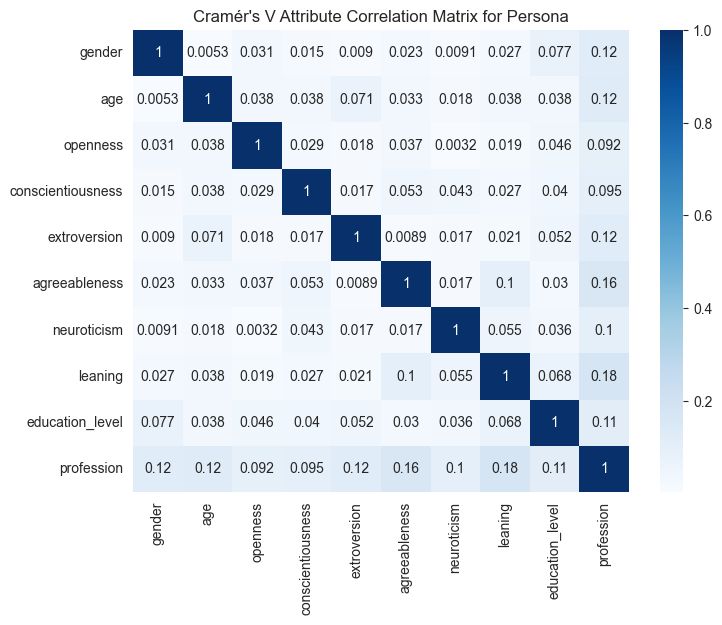

In [103]:
feature_cols = ['gender', 'age', 'openness', 'conscientiousness', 'extroversion', 'agreeableness',
                'neuroticism', 'leaning', 'education_level', 'profession']
features_df = personae[feature_cols].copy()

cvmatrix = cramers_v_matrix(features_df, label="Persona")

Features are not correlated, so we keep all of them.

Now we use OneHotEncoding to create feature vector and do clusterization on it, we want to obtain clusters of personae, assign the labels to them, and use it in analysing assortativity by persona and further analysis.

In [104]:
encoded_personae = pd.get_dummies(personae, columns=feature_cols, drop_first=False)

print(encoded_personae.shape)
encoded_personae.head()

(993, 33)


,id,gender_female,gender_male,age_middle,age_old,age_young,openness_consistent/cautious,openness_inventive/curious,conscientiousness_efficient/organized,conscientiousness_extravagant/careless,...,profession_Alternative,profession_Arts_Media,profession_Healthcare,profession_Law_Finance_Admin,profession_Retail_Service,profession_Science_Academia,profession_Security,profession_Skilled_Trades,profession_Technology,profession_Transport
1,2,True,False,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,3,False,True,False,False,True,False,True,True,False,...,False,False,False,False,False,False,False,True,False,False
3,4,True,False,True,False,False,False,True,True,False,...,False,False,True,False,False,False,False,False,False,False
4,5,True,False,True,False,False,False,True,False,True,...,False,False,False,False,True,False,False,False,False,False
5,6,False,True,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,True,False,False


We have 33 columns, one of them is id of agent, other are boolean values describing persona of agent.

The last step of creating persona is identifying different personae. We use k-means algorithm.

In [105]:
features = encoded_personae.copy().drop(['id'], axis=1)

In [106]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 16):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(features)
    score = silhouette_score(features, labels)
    scores.append(score)
    print(f"k={k} silhouette={score:.4f}")


k=2 silhouette=0.0697
k=3 silhouette=0.0698
k=4 silhouette=0.0683
k=5 silhouette=0.0736
k=6 silhouette=0.0703
k=7 silhouette=0.0750
k=8 silhouette=0.0759
k=9 silhouette=0.0774
k=10 silhouette=0.0712
k=11 silhouette=0.0792
k=12 silhouette=0.0793
k=13 silhouette=0.0762
k=14 silhouette=0.0737
k=15 silhouette=0.0764


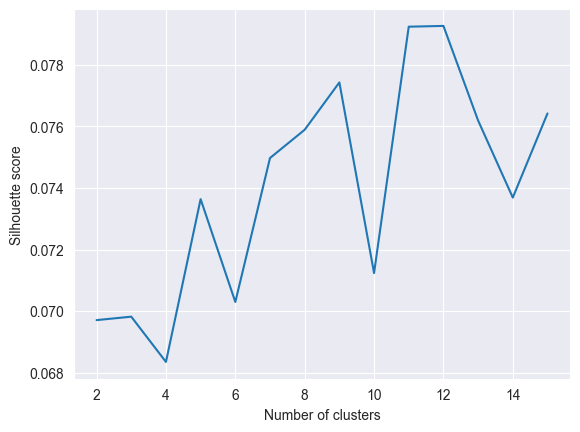

In [107]:
plt.plot(range(2, 16), scores)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()


More clusters we have the differences are smaller, but from psychological viewpoint the optimal number of clusters should be between 4 and 6. We chose 5 (maybe we will experiment with other values). For higher values the interpretability decreases.

In [108]:
k_best = 5

kmeans = KMeans(n_clusters=k_best, random_state=42)
personae['persona'] = kmeans.fit_predict(features)

personae['persona'].value_counts()

persona
4    229
2    207
3    199
0    183
1    175
Name: count, dtype: int64

We define categories for personae.

In [109]:
persona_map = {
    0: 'Persona_1',
    1: 'Persona_2',
    2: 'Persona_3',
    3: 'Persona_4',
    4: 'Persona_5',
}

personae['persona'] = personae['persona'].map(persona_map)

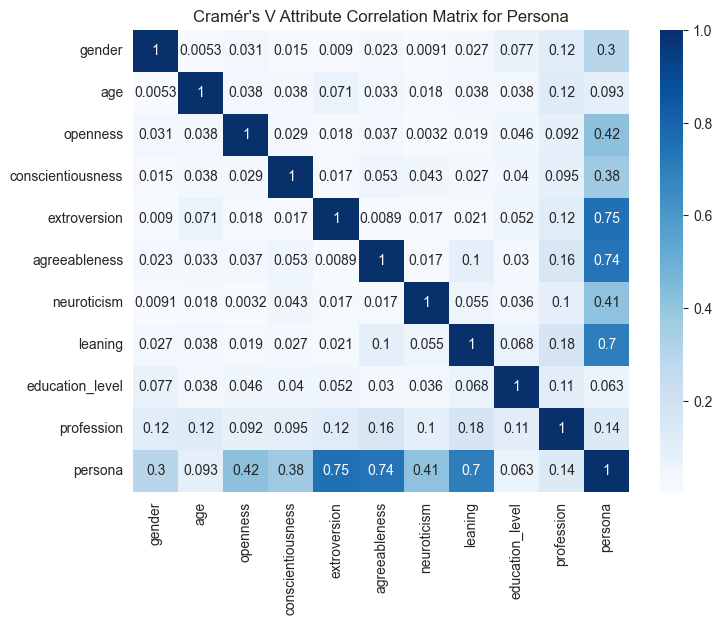

In [110]:
features_df['persona'] = personae['persona']

cvmatrix = cramers_v_matrix(features_df, label="Persona")

We check correlations between features again. It shows that Big Five is the most important feature. Age and education do not matter, what has psychological sense. Interesting.

Finally, we have one column describing personality, so we can add it as attribute to node and analyse assortativity and homofily in social network.

#### Persona clusters validation

We want to validate clusters and check which features describe each persona.

In [111]:
gender = pd.crosstab(personae['persona'], personae['gender'], normalize='index')
openness = pd.crosstab(personae['persona'], personae['openness'], normalize='index')
conscientiousness = pd.crosstab(personae['persona'], personae['conscientiousness'], normalize='index')
extroversion = pd.crosstab(personae['persona'], personae['extroversion'], normalize='index')
agreeableness = pd.crosstab(personae['persona'], personae['agreeableness'], normalize='index')
neuroticism = pd.crosstab(personae['persona'], personae['neuroticism'], normalize='index')
leaning = pd.crosstab(personae['persona'], personae['leaning'], normalize='index')

persona_description = (gender.join(openness, on=['persona']).
                       join(conscientiousness, on=['persona']).
                       join(extroversion, on=['persona']).
                       join(agreeableness, on=['persona']).
                       join(neuroticism, on=['persona']).
                       join(leaning, on=['persona']))

persona_description

,female,male,consistent/cautious,inventive/curious,efficient/organized,extravagant/careless,outgoing/energetic,solitary/reserved,critical/judgmental,friendly/compassionate,resilient/confident,sensitive/nervous,democrat,republican
persona,,,,,,,,,,,,,,
Persona_1,0.404372,0.595628,0.743169,0.256831,0.830601,0.169399,0.366120,0.633880,0.923497,0.076503,0.207650,0.792350,0.808743,0.191257
Persona_2,0.337143,0.662857,0.125714,0.874286,0.280000,0.720000,0.382857,0.617143,0.948571,0.051429,0.811429,0.188571,0.794286,0.205714
Persona_3,0.589372,0.410628,0.444444,0.555556,0.594203,0.405797,1.000000,0.000000,0.560386,0.439614,0.352657,0.647343,0.000000,1.000000
Persona_4,0.381910,0.618090,0.688442,0.311558,0.346734,0.653266,0.859296,0.140704,0.050251,0.949749,0.663317,0.336683,0.804020,0.195980
Persona_5,0.720524,0.279476,0.427948,0.572052,0.475983,0.524017,0.000000,1.000000,0.165939,0.834061,0.506550,0.493450,0.209607,0.790393


Table describing personae:

| Persona | Label                | Key Identity                          |
| ------- | -------------------- | ------------------------------------- |
| 1       | Cautious Skeptic     | Structured, critical, introverted     |
| 2       | Confident Maverick   | Creative, bold, independent           |
| 3       | Expressive Dominant  | Highly social, emotional, ideological |
| 4       | Empathic Extrovert   | Warm, prosocial leader                |
| 5       | Introverted Idealist | Reflective, creative loner            |


Below statistical method, which confirm Cramer's matrix results. It evaluates significance of personae - p-value.

In [112]:
def persona_significance(df, col):
    table = pd.crosstab(df['persona'], df[col])
    chi2, p, dof, expected = chi2_contingency(table)
    return p

for col in feature_cols:
    print(col, persona_significance(personae, col))

gender 4.430439611533095e-18
age 0.02820654890196283
openness 4.2370136228456734e-37
conscientiousness 2.3687903173938024e-29
extroversion 4.1312302027077906e-120
agreeableness 3.3479080866616943e-115
neuroticism 1.2538527887166717e-35
leaning 2.3743737522418305e-104
education_level 0.46134245108632976
profession 0.011575887305527314


Persona clusters are psychologically grounded. Clusters represent personality not demographics.

### Follow analysis

In [113]:
# check number of followings
follow_sum = pd.read_sql("SELECT COUNT(id) as follow_sum FROM follow;", conn)
follow_init = pd.read_sql("SELECT COUNT(id) as follow_init FROM follow WHERE round=0;", conn)
print(f"Followings in round 0: {follow_init['follow_init']}\n"
      f"Followings at the end: {follow_sum['follow_sum']}\n"
      f"New followings in 60 days: {follow_sum['follow_sum'] - follow_init['follow_init']}")

Followings in round 0: 0    29536
Name: follow_init, dtype: int64
Followings at the end: 0    59435
Name: follow_sum, dtype: int64
New followings in 60 days: 0    29899
dtype: int64


In [114]:
# check number of users
pd.read_sql("SELECT COUNT(DISTINCT user_id) FROM follow;", conn)

,COUNT(DISTINCT user_id)
0,993


#### Visualization

In [115]:
# # initial graph
# follow_0 = pd.read_sql("SELECT * FROM follow WHERE round=0;", conn)
#
# G = nx.from_pandas_edgelist(follow_0, source="follower_id", target="user_id", create_using=nx.DiGraph())
#
# plt.figure(figsize=(10, 10))
# pos = nx.spring_layout(G, k=0.15)  # layout algorithm
# nx.draw(G, pos, node_size=20, alpha=0.7, with_labels=False)
# plt.show()

In [116]:
# # example round -> the last one
# follow_1359 = pd.read_sql("SELECT * FROM follow WHERE round=1359;", conn)
#
# G = nx.from_pandas_edgelist(follow_1359, source="follower_id", target="user_id", create_using=nx.DiGraph())
#
# plt.figure(figsize=(8, 8), facecolor="white")
# pos = nx.spring_layout(G, k=0.15)  # layout algorithm
# nx.draw(G, pos, node_size=20, alpha=0.7, with_labels=False)
# plt.show()

In [117]:
# final graph
follow = pd.read_sql("SELECT * FROM follow;", conn)

G_follow = nx.from_pandas_edgelist(follow, source="follower_id", target="user_id", create_using=nx.DiGraph())

# plt.figure(figsize=(10, 10))
# pos = nx.spring_layout(G_follow, k=0.15)  # layout algorithm
# nx.draw(G_follow, pos, node_size=20, alpha=0.7, with_labels=False)
# plt.show()

In [118]:
avg_deg = sum(dict(G_follow.degree()).values()) / G_follow.number_of_nodes()
dens = nx.density(G_follow)
diam = nx.diameter(G_follow.to_undirected()) # Longest shortest path between any two nodes
print(f"Mean degree: {avg_deg:.2f}, Density: {dens:.4f}, Diameter: {diam}")

Mean degree: 118.55, Density: 0.0598, Diameter: 3


#### Degree

Degree = number of connections per node.

In-degree → number of followers (how many follow me)

Out-degree → number of people I follow.

Weighted degree = same, but if edges had weights (e.g., number of interactions). # maybe later

In [119]:
# For directed graphs:
in_deg = dict(G_follow.in_degree())
out_deg = dict(G_follow.out_degree())

# Convert to dataframe
deg_df = pd.DataFrame({
    'node': list(G_follow.nodes()),
    'in_degree': [in_deg.get(n, 0) for n in G_follow.nodes()],
    'out_degree': [out_deg.get(n, 0) for n in G_follow.nodes()],
    'total_degree': [in_deg.get(n, 0) + out_deg.get(n, 0) for n in G_follow.nodes()]
})

print(f"Mean total degree: {deg_df['total_degree'].mean()}\n"
      f"Mean in_degree: {deg_df['in_degree'].mean()}\n"
      f"Mean out_degree: {deg_df['out_degree'].mean()}\n")

print(f"Median total degree: {deg_df['total_degree'].median()}\n"
      f"Median in_degree: {deg_df['in_degree'].median()}\n"
      f"Median out_degree: {deg_df['out_degree'].median()}\n")

deg_df.sort_values('total_degree', ascending=False).head()

Mean total degree: 118.54783484390735
Mean in_degree: 59.273917421953676
Mean out_degree: 59.273917421953676

Median total degree: 101.0
Median in_degree: 50.0
Median out_degree: 51.0



,node,in_degree,out_degree,total_degree
17,19,211,217,428
16,18,210,210,420
19,21,206,194,400
18,20,191,197,388
384,27,190,191,381


#### Centrality

- Betweenness centrality - Measures how often a node lies on shortest paths between other nodes. High betweenness → “bridge” nodes connecting communities.
- Eigenvector centrality - Measures influence based on connections to other influential nodes. Think “a node is important if it’s connected to other important nodes”.

In [120]:
bet = nx.betweenness_centrality(G_follow)

eig = nx.eigenvector_centrality_numpy(G_follow)

centrality_df = pd.DataFrame({
    'node': list(G_follow.nodes()),
    'betweenness': [bet.get(n, 0) for n in G_follow.nodes()],
    'eigenvector': [eig.get(n, 0) for n in G_follow.nodes()],
})
centrality_df.head()

,node,betweenness,eigenvector
0,3,0.003796,0.053756
1,2,0.007611,0.081810
2,4,0.002476,0.051097
3,5,0.000770,0.028380
4,6,0.003366,0.053419


#### K-core (rdzeń sieci) — using igraph

The k-core is the maximal subgraph where each node has at least k connections.
Nodes with higher core numbers are more centrally embedded in the network.

In [121]:
import igraph as ig

# Convert from networkx to igraph
ig_graph = ig.Graph.TupleList(G_follow.edges(), directed=True)

# Compute core numbers (k-shell decomposition)
core_numbers = ig_graph.coreness(mode="ALL")

# Attach to dataframe
kcore_df = pd.DataFrame({
    'node': ig_graph.vs['name'],
    'kcore': core_numbers
})
kcore_df.head()

,node,kcore
0,3,74
1,2,74
2,18,74
3,19,74
4,20,74


#### Community detection (Modularność / Społeczności) — Leiden Algorithm

Communities are clusters of nodes more connected internally than externally.
The Leiden algorithm (improved Louvain) finds such groups and the modularity score quantifies how good the division is (0–1 scale).

In [122]:
import leidenalg as la

# Using same igraph object

partition = la.find_partition(ig_graph, partition_type=la.ModularityVertexPartition)
modularity = partition.modularity

community_df = pd.DataFrame({
    'node': ig_graph.vs['name'],
    'community': partition.membership
})

print(f"Modularity score: {modularity:.3f}")
community_df.head()

Modularity score: 0.102


,node,community
0,3,0
1,2,0
2,18,0
3,19,0
4,20,0


#### Adding *persona* attribute to the *Follow* graph

User *Admin* does not have any connection in network.

In [123]:
follow = pd.read_sql("SELECT * FROM follow;", conn)

G_follow = nx.from_pandas_edgelist(follow, source="follower_id", target="user_id", create_using=nx.DiGraph())

In [124]:
# mapping
persona_dict = personae.set_index('id')['persona'].to_dict()

# add attributes to nodes
nx.set_node_attributes(G_follow, persona_dict, "persona")

# check
for node in list(G_follow.nodes())[:5]:
    print(node, G_follow.nodes[node])

3 {'persona': 'Persona_3'}
2 {'persona': 'Persona_4'}
4 {'persona': 'Persona_3'}
5 {'persona': 'Persona_4'}
6 {'persona': 'Persona_2'}


#### Assortativity by persona (asortatywność względem persony) ~ Homophily

Measures how strongly nodes connect to similar others based on a categorical or numeric attribute.
- Positive (close to +1): “birds of a feather” — users connect mostly to others with the same persona.
- Negative (close to -1): heterophily — users tend to connect with different personas.
- 0: no particular preference (random mixing).

In your case it is tendency for users to follow others of the same persona type.

In [125]:
assortativity = nx.attribute_assortativity_coefficient(G_follow, 'persona')
print("Persona assortativity:", assortativity)

Persona assortativity: -0.0008912753476242735


:(

Random mixing...

In [126]:
# persona_colors = {
#     "Persona_1": "red",
#     "Persona_2": "blue",
#     "Persona_3": "green",
#     "Persona_4": "orange",
#     "Persona_5": "purple"
# }
#
# # subset =
#
# node_colors = [
#     persona_colors.get(G_follow.nodes[n].get("persona"), "gray")
#     for n in G_follow.nodes()
# ]
#
# plt.figure(figsize=(10,10))
# pos = nx.spring_layout(G_follow, k=0.15)
# nx.draw(G_follow, pos, node_color=node_colors, node_size=30, alpha=0.8, with_labels=False)
# plt.title("Network colored by Persona")
# plt.show()

#### Metrics analysis

In [127]:
metrics = (
    deg_df
    .merge(centrality_df, on='node', how='left')
    .merge(kcore_df, on='node', how='left')
    .merge(community_df, on='node', how='left')
)
metrics.head()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,kcore,community
0,3,122,119,241,0.003796,0.053756,74,0
1,2,171,189,360,0.007611,0.081810,74,0
2,4,110,102,212,0.002476,0.051097,74,2
3,5,60,64,124,0.000770,0.028380,74,1
4,6,120,122,242,0.003366,0.053419,74,1


In [128]:
metrics.describe()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,kcore,community
count,993.00000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000
mean,498.00000,59.273917,59.273917,118.547835,0.001022,0.027442,66.927492,2.462236
std,286.79871,34.382243,31.748912,65.752530,0.001320,0.015945,9.600738,1.970763
min,2.00000,9.000000,17.000000,28.000000,0.000022,0.003984,28.000000,0.000000
25%,250.00000,34.000000,36.000000,70.000000,0.000265,0.015856,61.000000,1.000000
50%,498.00000,50.000000,51.000000,101.000000,0.000571,0.023244,73.000000,2.000000
75%,746.00000,74.000000,75.000000,148.000000,0.001206,0.034202,74.000000,4.000000
max,994.00000,211.000000,217.000000,428.000000,0.011050,0.099854,74.000000,6.000000


In [129]:
sns.set_style("white")
sns.set_context("notebook")

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

plt.style.use("default")  # reset backend theme
sns.set_theme(style="white")  # enforce seaborn white theme

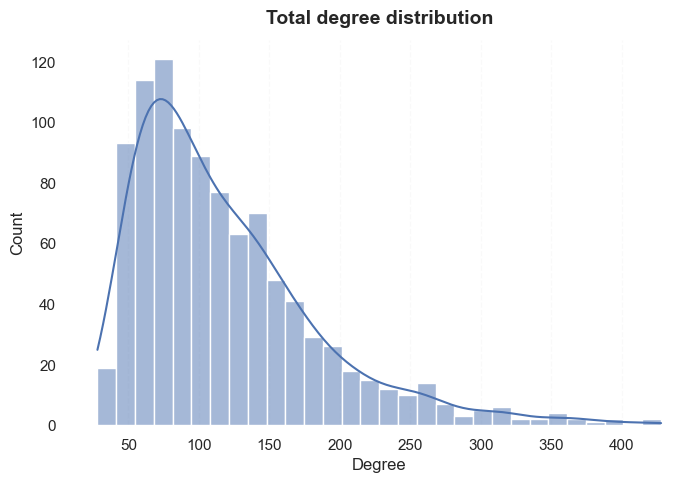

In [130]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
sns.histplot(metrics['total_degree'], bins=30, kde=True, ax=ax) # color=sns.color_palette("pastel")[0]  color="#ff9ecb",
ax.set_title("Total degree distribution", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Degree", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.1)
sns.despine(left=True, bottom=True)
plt.show()

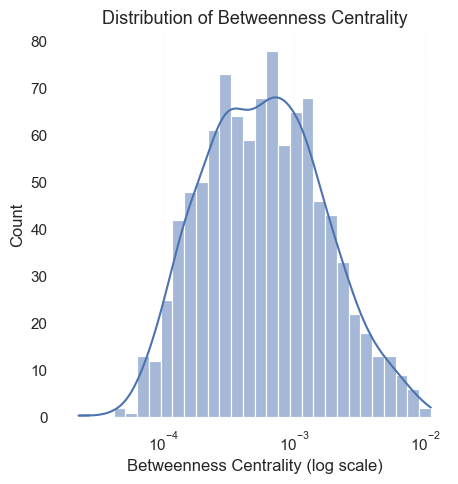

In [131]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.histplot(metrics['betweenness'], bins=30, kde=True, log_scale=True, ax=ax)
ax.set_xlabel("Betweenness Centrality (log scale)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of Betweenness Centrality", fontsize=13)
ax.grid(axis="x", linestyle="--", alpha=0.1)
sns.despine(left=True, bottom=True)
plt.show()

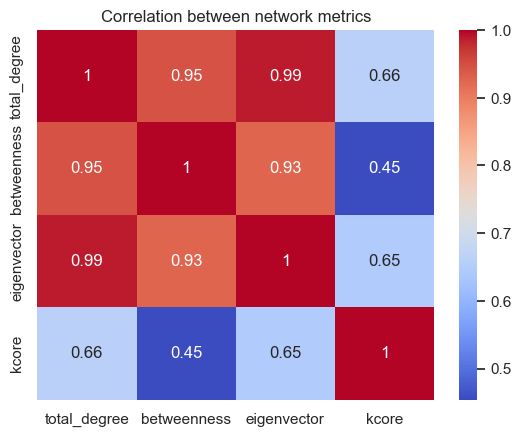

In [132]:
corr = metrics[['total_degree', 'betweenness', 'eigenvector', 'kcore']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation between network metrics")
plt.show()


In [133]:
# Compare groups
metrics.groupby('community')['total_degree'].median().sort_values(ascending=False)

community
1    118.0
6    117.0
2    114.0
5    101.0
4     92.0
3     90.0
0     83.0
Name: total_degree, dtype: float64

### Metrics vs Persona

In [142]:
in_deg = dict(G_follow.in_degree())
out_deg = dict(G_follow.out_degree())
total_deg = dict(G_follow.degree())

betweenness = nx.betweenness_centrality(G_follow, normalized=True)
pagerank = nx.pagerank(G_follow, alpha=0.85)

kcore = nx.core_number(G_follow.to_undirected())

metrics = pd.DataFrame({
    'node': list(G_follow.nodes()),
    'persona': [G_follow.nodes[n].get('persona') for n in G_follow.nodes()],
    'in_degree': [in_deg[n] for n in G_follow.nodes()],
    'out_degree': [out_deg[n] for n in G_follow.nodes()],
    'total_degree': [total_deg[n] for n in G_follow.nodes()],
    'betweenness': [betweenness[n] for n in G_follow.nodes()],
    'pagerank': [pagerank[n] for n in G_follow.nodes()],
    'kcore': [kcore[n] for n in G_follow.nodes()]
})

In [143]:
persona_summary = metrics.groupby('persona').agg(
    n_nodes=('node', 'count'),
    mean_in_degree=('in_degree', 'mean'),
    mean_out_degree=('out_degree', 'mean'),
    mean_total_degree=('total_degree', 'mean'),
    mean_betweenness=('betweenness', 'mean'),
    median_betweenness=('betweenness', 'median'),
    mean_pagerank=('pagerank', 'mean'),
    mean_kcore=('kcore', 'mean')
).sort_values('mean_pagerank', ascending=False)

persona_summary

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,median_betweenness,mean_pagerank,mean_kcore
persona,,,,,,,,
Persona_1,183,61.065574,61.060109,122.125683,0.001146,0.000527,0.001032,44.530055
Persona_4,199,60.412060,60.547739,120.959799,0.001067,0.000631,0.001023,44.753769
Persona_3,207,58.623188,59.256039,117.879227,0.001033,0.000530,0.000997,44.541063
Persona_2,175,58.394286,58.194286,116.588571,0.000931,0.000586,0.000995,45.171429
Persona_5,229,58.113537,57.580786,115.694323,0.000942,0.000583,0.000992,44.890830


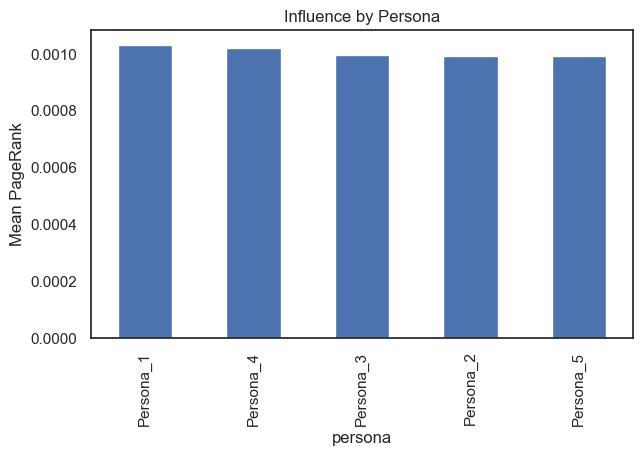

In [144]:
persona_summary['mean_pagerank'].plot(kind='bar', figsize=(7,4))
plt.ylabel("Mean PageRank")
plt.title("Influence by Persona")
plt.show()

In [145]:
global_mean = metrics['pagerank'].mean()

persona_summary['pagerank_ratio'] = (
    persona_summary['mean_pagerank'] / global_mean
)

persona_summary[['mean_pagerank', 'pagerank_ratio']]

,mean_pagerank,pagerank_ratio
persona,,
Persona_1,0.001032,1.024642
Persona_4,0.001023,1.015488
Persona_3,0.000997,0.990458
Persona_2,0.000995,0.987673
Persona_5,0.000992,0.984894


In [146]:
from scipy.stats import kruskal

groups = [
    metrics[metrics['persona'] == p]['betweenness']
    for p in metrics['persona'].unique()
]

kruskal(*groups)

KruskalResult(statistic=np.float64(0.3956972090850286), pvalue=np.float64(0.9828276681714267))

## Using ***ysight***

In [134]:
# Initialize data handler
ydh = YDataHandler(db_path)

# Get simulation time range
time_range = ydh.time_range()
print(f"Simulation: rounds {time_range['min_round']} to {time_range['max_round']}")

# Get all agents
agents = ydh.agents()
print(f"Total agents: {len(agents.get_agents())}")

# Extract social network
network = ydh.social_network()
print(f"Network: {network.number_of_nodes()} nodes, {network.number_of_edges()} edges")

Simulation: rounds 1 to 1444
Total agents: 994
Network: 993 nodes, 58535 edges


In [135]:
# Look at the first agent
first_agent = agents.get_agents()[0]
print("\nFirst Agent Properties:")
print(f"  ID: {first_agent.id}")
print(f"  Age: {first_agent.age}")
print(f"  Gender: {first_agent.gender}")
print(f"  Education: {first_agent.education}")


First Agent Properties:
  ID: 1
  Age: 0
  Gender: 3
  Education: None


In [136]:
# Get agents with age 25
young_agents = ydh.agents_by_feature('age', 25)
print(f"Agents aged 25: {len(young_agents.get_agents())}")

# Get agents by gender
female_agents = ydh.agents_by_feature('gender', 'F')
print(f"Female agents: {len(female_agents.get_agents())}")

Agents aged 25: 22
Female agents: 0


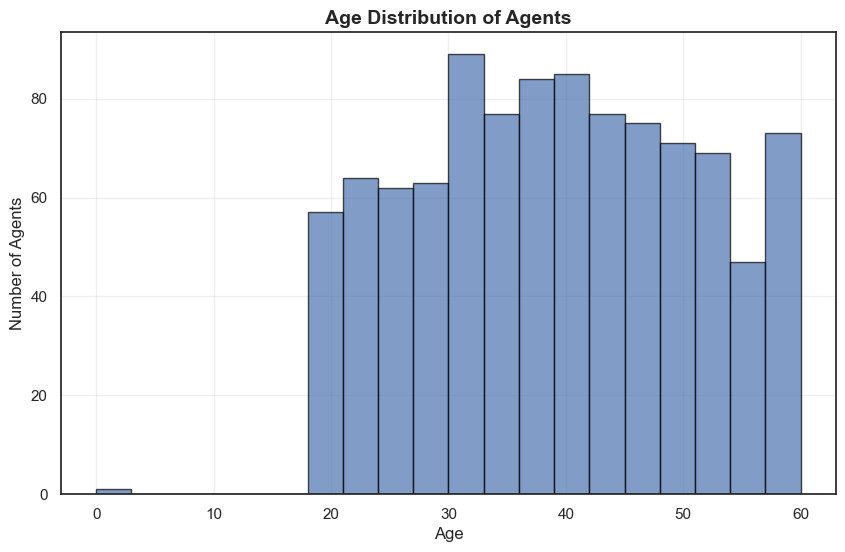

In [137]:
# Collect ages
ages = [agent.age for agent in agents.get_agents()]

# Plot age distribution
plt.figure(figsize=(10, 6))
plt.hist(ages, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Agents', fontsize=12)
plt.title('Age Distribution of Agents', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

In [138]:
# Get posts by a specific agent
agent_id = 857  # Change this to any valid agent ID
agent_posts = ydh.posts_by_agent(agent_id)

print(f"Agent {agent_id} created {len(agent_posts.get_posts())} posts")

# Examine the first post
if agent_posts.get_posts():
    first_post = agent_posts.get_posts()[0]
    print("\nFirst Post Details:")
    print(f"  Post ID: {first_post.id}")
    print(f"  Author: {first_post.user_id}")
    print(f"  Round: {first_post.round}")
    print(f"  Topic: {first_post.topics}")
    print(f"  Emotion: {first_post.emotions}")

Agent 857 created 158 posts

First Post Details:
  Post ID: 4
  Author: 857
  Round: 1
  Topic: []
  Emotion: []


In [139]:
# Get interest profile for an agent
agent_id = 1
profile = ydh.agent_interests(agent_id)

print(f"Interest Profile for Agent {agent_id}:")
for topic, score in list(profile.items())[:5]:  # Show top 5 topics
    print(f"  Topic {topic}: {score:.3f}")

Interest Profile for Agent 1:


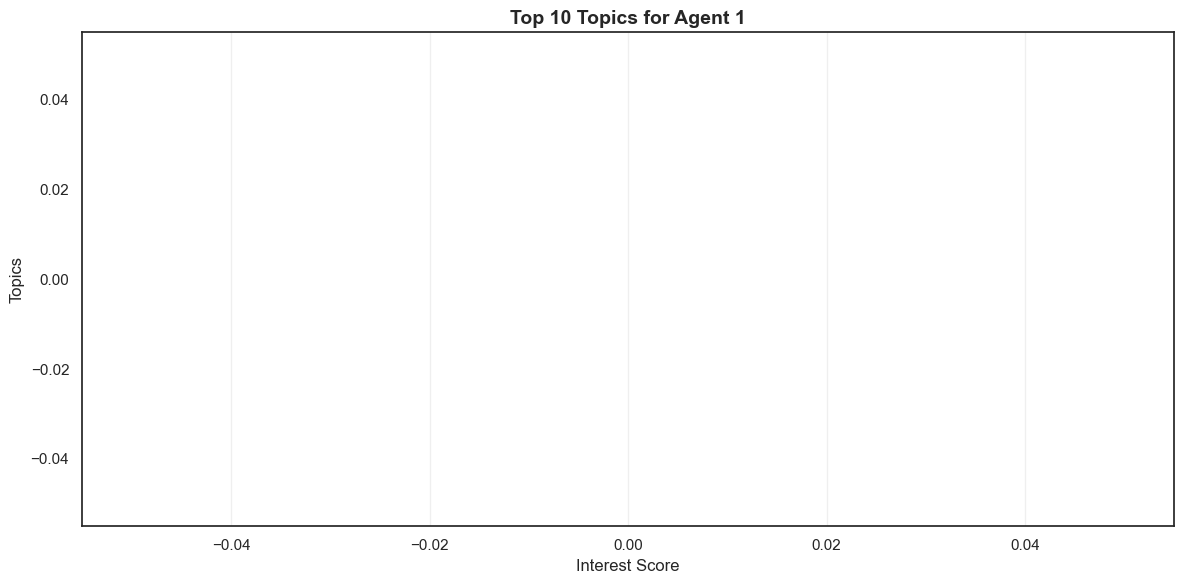

In [140]:
# Get top topics for visualization
sorted_topics = sorted(profile.items(), key=lambda x: x[1], reverse=True)[:10]
topics = [f"Topic {t[0]}" for t in sorted_topics]
scores = [t[1] for t in sorted_topics]

# Create bar plot
plt.figure(figsize=(12, 6))
plt.barh(topics, scores, color='steelblue', alpha=0.8)
plt.xlabel('Interest Score', fontsize=12)
plt.ylabel('Topics', fontsize=12)
plt.title(f'Top 10 Topics for Agent {agent_id}', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [141]:
# Example: Get top 5 most active agents
query = """
    SELECT user_id, COUNT(*) as post_count
    FROM post
    GROUP BY user_id
    ORDER BY post_count DESC
    LIMIT 5
"""

results = ydh.custom_query(query)
print("Top 5 Most Active Agents:")
for i, row in enumerate(results, 1):
    print(f"  {i}. Agent {row[0]}: {row[1]} posts")

Top 5 Most Active Agents:
  1. Agent 124: 323 posts
  2. Agent 321: 312 posts
  3. Agent 192: 311 posts
  4. Agent 764: 297 posts
  5. Agent 246: 283 posts
